In [1]:
import sys
sys.path.append('/home/igavier_umass_edu/Documents/Neuromorphic-IMU/snn/')
from utils_datasets import *
from utils_architectures import *

import os
import glob
from tqdm import tqdm

import numpy as np
import pandas as pd
import json
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sn
from statannotations.Annotator import Annotator
plt.rcParams['figure.dpi'] = 150

os.environ['WANDB_SILENT'] = 'True'
os.environ['WANDB_ENTITY'] = 'igavier'
os.environ['WANDB_PROJECT'] = 'Neuromorphic-IMU'
os.environ['WANDB_NOTEBOOK_NAME'] = 'wandb_metrics.ipynb'

In [2]:
import wandb
api = wandb.Api(timeout=500)

In [4]:
runs = api.runs(filters={'$and':[{'created_at':{
                                     '$gt':'2026-03-02',
                                     '$lt':'2026-03-20',
                                 }}]},
                order='-created_at')

# runs = [r for r in runs if 'ignore_run' not in r.tags]
runs = [r for r in runs if '_step' in r.summary]
runs = [r for r in runs if r.summary['_step'] >= 1]
runs = [r for r in runs if ((r.config['use_xylo'] and r.config['time_compress'] == 1) or not r.config['use_xylo'])]
runs = [r for r in runs if r.config['network_type'] == 'SynNetRP']
# runs = [r for r in runs if r.config['dataset_name'] == 'Realworld']
# runs = [r for r in runs if r.config['time_compress'] > 10]
runs = [r for r in runs if r.config['save_model']]
# runs = [r for r in runs if tuple(r.config['neurons_network']) == (80,80,80)]
# runs = [r for r in runs if r.config['random_seed'] <= 5]
# runs = [r for r in runs if r.config['shift_syn'] == 1]
# runs = [r for r in runs if r.config['shift_mem'] == 1]
# runs = [r for r in runs if 'dataset_name' in r.config and r.config['dataset_name'] == 'Realworld']
# runs = [r for r in runs if tuple(r.config['subject_splits']) == (10,2,2)]
# runs = [r for r in runs if r.config['time_compress'] == 8.0]

random_seeds = list(range(1, 6))  # Random seeds from 1 to 5
methods = [False, True] # NIMU or Xylo
subject_splits = [(50,20,20),(75,20,20),(100,20,20)]
desired_combinations = {(seed, method, subject_split) for seed in random_seeds
                        for method in methods for subject_split in subject_splits}

# # Filter runs
# filtered_runs = []
# seen_combinations = set()
# for r in runs:
#     seed = r.config.get('random_seed')
#     method = r.config.get('use_xylo')
#     subject_split = tuple(r.config.get('subject_splits'))
#     if (seed, method, subject_split) in desired_combinations and (seed, method, subject_split) not in seen_combinations:
#         filtered_runs.append(r)
#         seen_combinations.add((seed, method, subject_split))
#     if len(filtered_runs) == len(desired_combinations): # Stop when all combinations are covered
#         break

# runs = filtered_runs

# Print the filtered runs
print(len(runs), 'runs')
print(f"Date\t\t\tID\t\tSeed\tUse Xylo\tSubject Splits\tStep")
for r in runs: print(f"{r.createdAt}\t{r.id}\t{r.config['random_seed']}\t{r.config['use_xylo']}\t\t{r.config['subject_splits']}\t{r.summary['_step']}")

200 runs
Date			ID		Seed	Use Xylo	Subject Splits	Step
2026-03-16T20:10:58Z	p8dfq22i	10	False		[80, 10, 10]	199
2026-03-16T20:10:24Z	947riyoh	10	False		[80, 10, 10]	199
2026-03-16T20:09:29Z	dv68ls9q	10	False		[80, 10, 10]	199
2026-03-16T20:07:57Z	yyokab3t	10	False		[80, 10, 10]	199
2026-03-16T20:07:22Z	2tqvflrl	9	False		[80, 10, 10]	199
2026-03-16T20:06:53Z	z3u5k7py	9	False		[80, 10, 10]	199
2026-03-16T20:06:21Z	3uj2hgs2	8	False		[80, 10, 10]	199
2026-03-16T20:06:14Z	lgiwql1x	9	False		[80, 10, 10]	199
2026-03-16T20:05:45Z	foec77oe	9	False		[80, 10, 10]	199
2026-03-16T20:04:46Z	kjm8v44k	8	False		[80, 10, 10]	199
2026-03-16T19:52:56Z	vtu72l2p	8	False		[80, 10, 10]	199
2026-03-16T19:52:40Z	g0o4k7kt	8	False		[80, 10, 10]	199
2026-03-16T19:51:53Z	l6aoc6yz	6	False		[80, 10, 10]	199
2026-03-16T19:51:50Z	ophfwv4l	6	False		[80, 10, 10]	199
2026-03-16T19:51:47Z	sh1iz6nr	1	False		[80, 10, 10]	199
2026-03-16T19:51:37Z	qunge3mu	7	False		[80, 10, 10]	199
2026-03-16T19:51:37Z	394vf672	7	False		[80, 10

In [5]:
# runs = runs[30:]
# _runs = []
# _runs += runs
# runs = _runs
# print(f"Date\t\t\tSeed\tUse Xylo\tSubject Splits\tStep")
# for r in _runs:
#     print(f"{r.createdAt}\t{r.config['random_seed']}\t{r.config['use_xylo']}\t\t{r.config['subject_splits']}\t{r.summary['_step']}")

In [6]:
columns = ['id', 'seed', 'method', 'tmCompress', 'nwSize', 'subjSplit', 'epoch',
           'TrLoss', 'VaLoss', 'TeLoss', 'TrSpk', 'VaSpk', 'TeSpk',
           'TrAcc', 'VaAcc', 'TeAcc', 'TrBalAcc', 'VaBalAcc', 'TeBalAcc',
           'TrAUCMa', 'VaAUCMa', 'TeAUCMa', 'TrAUCMi', 'VaAUCMi', 'TeAUCMi', 'TrAUCWe', 'VaAUCWe', 'TeAUCWe',
           'TrF1Ma', 'VaF1Ma', 'TeF1Ma', 'TrF1Mi', 'VaF1Mi', 'TeF1Mi', 'TrF1We', 'VaF1We', 'TeF1We',
           'TrKappa', 'VaKappa', 'TeKappa', 'TrPhi', 'VaPhi', 'TePhi']

dFAll = pd.DataFrame(columns=columns)

In [7]:
metrics = ['loss','spk','acc','bacc','auroc_mac','auroc_mic','auroc_wei','f1_mac','f1_mic','f1_wei','kappa','phi']
splits = ['train','val','test']

for run in tqdm(runs):
    method = (f"{run.config['network_type']},{'xylo' if run.config['use_xylo'] else 'nimu'},{run.config['dataset_name']}")
    row = [run.id, run.config['random_seed'], method,
           run.config['time_compress'] if 'time_compress' in run.config else 1,
           tuple(run.config['neurons_network']), tuple(run.config['subject_splits'])]
    keys = [f'{metric}/{split}' for metric in metrics for split in splits]
    history = run.scan_history(keys=keys)
    history = np.array([list(h.values()) for h in history])
    for h, hist in enumerate(history):
        dFAll.loc[len(dFAll)] = row + [h] + list(hist)

100%|██████████| 200/200 [06:01<00:00,  1.81s/it]


In [8]:
# dFAll.to_csv('../results/nature_experiments_2.csv')

In [9]:
# dFAll = pd.read_csv('../results/nature_experiments.csv', index_col=0)
# dFAll1 = pd.read_csv('../results/nature_experiments_1.csv', index_col=0)
# dFAll2 = pd.read_csv('../results/nature_experiments_2.csv', index_col=0)
# dFAll = pd.concat([dFAll[~dFAll['method'].str.contains('SynNetRP,.*,Realworld', regex=True)],
#                    dFAll1[~dFAll1['method'].str.contains('SynNetRP,xylo,Realworld', regex=True)],
#                    dFAll2], ignore_index=True)

In [10]:
dFAllOpt = dFAll.sort_values(['method','seed','tmCompress','nwSize','subjSplit','VaAUCMa','TrAUCMa'],
                             ascending=[False, True, True, True, True, False, False])
dFAllOpt = dFAllOpt.groupby(['method','seed','tmCompress','nwSize','subjSplit'], as_index=False).head(1)

display(dFAllOpt[['nwSize','method','tmCompress','TeAUCMa','TeBalAcc','TeSpk']]
        .groupby(['nwSize','method','tmCompress']).agg(['mean','std']).style.format('{:.3f}'))

In [16]:
# One "configuration" = same method, compression, network size, and subject split
config_cols = ['method', 'tmCompress', 'nwSize', 'subjSplit']

df_closest = dFAllOpt.copy()
df_closest['TeAUCMa_median_cfg'] = df_closest.groupby(config_cols)['TeAUCMa'].transform('median')
df_closest['abs_dist_to_median'] = (df_closest['TeAUCMa'] - df_closest['TeAUCMa_median_cfg']).abs()

closest_20 = (
    df_closest
    .sort_values(config_cols + ['abs_dist_to_median', 'seed'])  # tie-break by seed
    .groupby(config_cols, as_index=False)
    .head(1)
    .sort_values(config_cols)
)

print(f"Selected runs: {len(closest_20)}")
display(closest_20)

Selected runs: 20


,id,seed,method,tmCompress,nwSize,subjSplit,epoch,TrLoss,VaLoss,TeLoss,...,VaF1We,TeF1We,TrKappa,VaKappa,TeKappa,TrPhi,VaPhi,TePhi,TeAUCMa_median_cfg,abs_dist_to_median
28328,759030xw,5,"SynNetRP,nimu,Capture24",1,"(80, 80, 80)","(80, 10, 10)",14,1.437721,1.477847,1.397245,...,0.565031,0.660463,0.545015,0.489586,0.518085,0.551388,0.506345,0.530455,0.873407,0.000656
28116,ldjw7v8b,9,"SynNetRP,nimu,Capture24",2,"(80, 80, 80)","(80, 10, 10)",37,1.430818,1.454807,1.386855,...,0.556265,0.696022,0.537685,0.472595,0.560789,0.547369,0.485236,0.565392,0.877912,0.001413
28387,qu9s9j3n,5,"SynNetRP,nimu,Capture24",4,"(80, 80, 80)","(80, 10, 10)",25,1.430226,1.485186,1.387122,...,0.550614,0.658804,0.546250,0.475700,0.516507,0.552820,0.488152,0.531341,0.884997,0.000608
27104,iqb2c9ut,10,"SynNetRP,nimu,Capture24",8,"(80, 80, 80)","(80, 10, 10)",42,1.466327,1.443059,1.425767,...,0.626374,0.653733,0.499797,0.562400,0.522325,0.505033,0.565165,0.529305,0.879763,0.001156
2924,sh1iz6nr,1,"SynNetRP,nimu,MHealth",1,"(80, 80, 80)","(80, 10, 10)",124,1.975730,2.001692,2.348727,...,0.649084,0.272158,0.598958,0.666667,0.224232,0.608354,0.681005,0.304826,0.953975,0.001403
5598,zwa1rzlu,5,"SynNetRP,nimu,MHealth",2,"(80, 80, 80)","(80, 10, 10)",198,1.883104,1.939729,2.311309,...,0.551282,0.426361,0.703125,0.583333,0.241082,0.719131,0.601950,0.323433,0.963730,0.002211
3785,fjk6slk0,6,"SynNetRP,nimu,MHealth",4,"(80, 80, 80)","(80, 10, 10)",185,1.900051,1.983600,2.269314,...,0.651282,0.313462,0.796875,0.666667,0.203146,0.805679,0.684448,0.283609,0.953453,0.000597
6122,2y0o9f9x,5,"SynNetRP,nimu,MHealth",8,"(80, 80, 80)","(80, 10, 10)",122,1.961759,2.064462,2.487039,...,0.544322,0.209486,0.734375,0.583333,0.096037,0.744224,0.602980,0.140610,0.879573,0.007740
24809,0on8tc8h,4,"SynNetRP,nimu,Realworld",1,"(80, 80, 80)","(80, 10, 10)",133,1.568248,1.580200,1.631385,...,0.509966,0.375201,0.532407,0.515873,0.320060,0.559360,0.551770,0.343238,0.903566,0.000222
24207,2dnf9l79,4,"SynNetRP,nimu,Realworld",2,"(80, 80, 80)","(80, 10, 10)",131,1.567322,1.591111,1.626405,...,0.509847,0.477000,0.555556,0.523810,0.473000,0.576818,0.539847,0.509695,0.904359,0.001276


In [17]:
models_dir = '/home/igavier_umass_edu/Documents/Neuromorphic-IMU/snn/models/'

rows = []
for _, r in closest_20.iterrows():
    run_id = str(r['id'])
    seed = r['seed']
    method = r['method']
    tc = r['tmCompress']
    auc = r['TeAUCMa']
    acc = r['TeAcc']
    matches = sorted(glob.glob(os.path.join(models_dir, f'*_{run_id}.pth')))
    
    if matches:
        for f in matches:
            rows.append({'filename': os.path.basename(f), 'seed': seed, 'method': method, 'tmCompress': tc,
                         'auroc': auc, 'accuracy': acc})
    else:
        rows.append({'filename': f'[MISSING] *_{run_id}.pth', 'seed': seed, 'method': method, 'tmCompress': tc,
                     'auroc': auc, 'accuracy': acc})

df_model_files = pd.DataFrame(rows).sort_values(['method', 'tmCompress', 'seed', 'filename']).reset_index(drop=True)
display(df_model_files)
print(f"Found {sum(~df_model_files['filename'].str.startswith('[MISSING]'))} file(s) for {len(closest_20)} runs.")

,filename,seed,method,tmCompress,auroc,accuracy
0,2026-03-05T00:05:04.990914106+00:00_759030xw.pth,5,"SynNetRP,nimu,Capture24",1,0.874063,0.668475
1,2026-03-05T00:05:19.248961926+00:00_ldjw7v8b.pth,9,"SynNetRP,nimu,Capture24",2,0.876499,0.695176
2,2026-03-05T00:05:04.521979094+00:00_qu9s9j3n.pth,5,"SynNetRP,nimu,Capture24",4,0.884388,0.667149
3,2026-03-05T00:07:38.731547117+00:00_iqb2c9ut.pth,10,"SynNetRP,nimu,Capture24",8,0.878607,0.651703
4,2026-03-16T19:51:46.602777958+00:00_sh1iz6nr.pth,1,"SynNetRP,nimu,MHealth",1,0.955379,0.296137
5,2026-03-16T19:51:21.644325972+00:00_zwa1rzlu.pth,5,"SynNetRP,nimu,MHealth",2,0.965941,0.388889
6,2026-03-16T19:51:31.486196041+00:00_fjk6slk0.pth,6,"SynNetRP,nimu,MHealth",4,0.954049,0.295019
7,2026-03-16T19:51:21.947024107+00:00_2y0o9f9x.pth,5,"SynNetRP,nimu,MHealth",8,0.887314,0.188889
8,2026-03-05T00:15:15.798122883+00:00_0on8tc8h.pth,4,"SynNetRP,nimu,Realworld",1,0.903788,0.413984
9,2026-03-05T00:18:12.145109892+00:00_2dnf9l79.pth,4,"SynNetRP,nimu,Realworld",2,0.905635,0.546060


Found 20 file(s) for 20 runs.


/tmp/ipykernel_1472610/1182747824.py:31: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sn.lineplot(
/tmp/ipykernel_1472610/1182747824.py:31: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sn.lineplot(


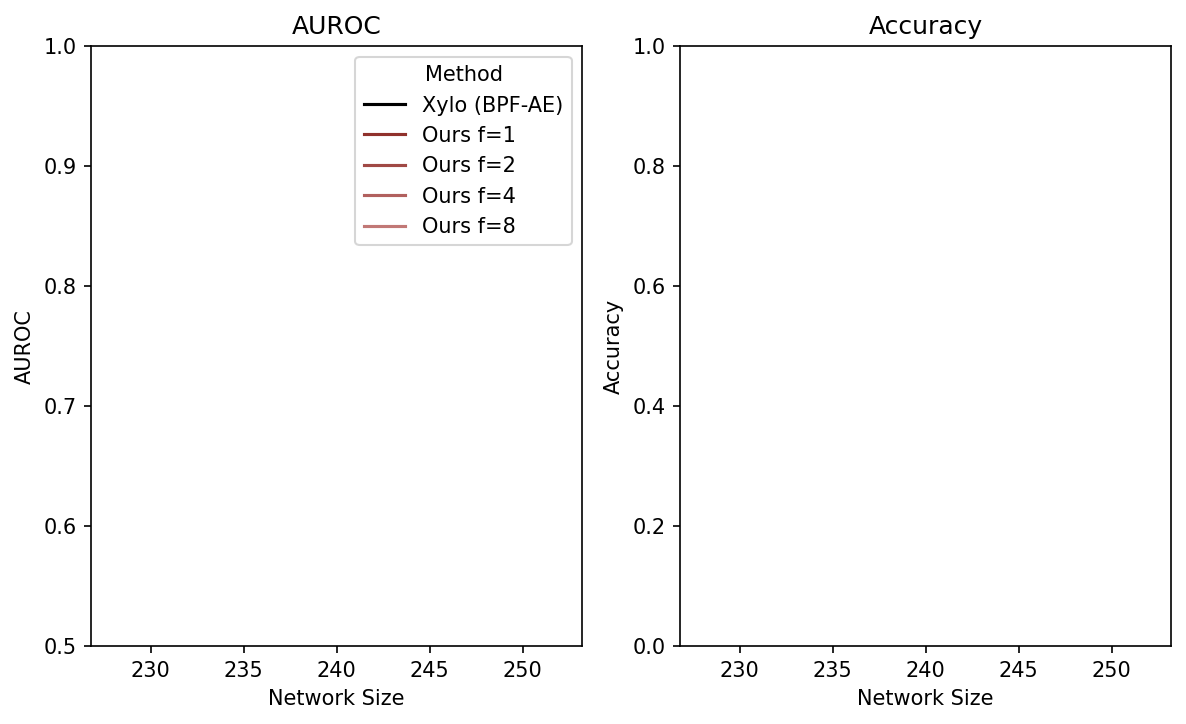

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(8,5), sharex=True, sharey=False)
fig.subplots_adjust(bottom=0.12, top=0.92, left=0.07, right=0.97)

dataset = 'Realworld'

for axi, metric in zip(ax, ['AUROC','Accuracy']):
    df = dFAllOpt[dFAllOpt['method'].str.contains(f'SynNetRP,.*,{dataset}', regex=True)].copy()
    # df.TeBalAcc *= 100
    # df.TeSpk /= 5
    df.nwSize = df.nwSize.apply(sum)
    df = df.rename(columns={'TeAUCMa': 'AUROC'})
    df = df.rename(columns={'TeBalAcc': 'Accuracy'})

    # original hue key (tuple)
    df["hue_key"] = df[['method','tmCompress']].apply(tuple, axis=1)

    # map to pretty names
    hue_order_key = [
        (f'SynNetRP,xylo,{dataset}', 1.0),
        (f'SynNetRP,nimu,{dataset}', 1.0),
        (f'SynNetRP,nimu,{dataset}', 2.0),
        (f'SynNetRP,nimu,{dataset}', 4.0),
        (f'SynNetRP,nimu,{dataset}', 8.0),
    ]
    hue_order = ['Xylo (BPF-AE)', 'Ours f=1', 'Ours f=2', 'Ours f=4', 'Ours f=8']

    label_map = dict(zip(hue_order_key, hue_order))
    df["Method"] = df["hue_key"].map(label_map)

    # keep order stable
    df["Method"] = pd.Categorical(df["Method"], categories=hue_order, ordered=True)

    sn.scatterplot(
        data=df,
        x='Method', y=metric,
        hue='Method',
        hue_order=hue_order,
        # size='Accuracy',
        # size_order=[40,50,60],
        # sizes=(20, 100),
        palette=['black'] + sn.color_palette('blend:#90312C,#E2A7A8', n_colors=6),
        ax=axi
    )

    axi.set_title(metric)
    axi.set_xlabel('Network Size')
    axi.set_ylabel(metric)
    axi.set_ylim(0.5 if axi == ax[0] else 0, 1)
    if axi != ax[0]: axi.get_legend().remove()

# axi.set_xscale('log')
# axi.set_xlim(5e2, 2e4)
# axi.set_ylim(0, 1)

# fig.savefig('../results/auroc_spikes.pdf', dpi=150)

### Confusion matrices

In [25]:
label_names_realworld = ['climbingdown', 'climbingup', 'jumping', 'lying',
                         'running', 'sitting', 'standing', 'walking']

conf_mats = dict([(k, np.zeros(2*(len(label_names_realworld),))) for k in dFAllOpt.id.unique()])
for run in tqdm(runs):
    if run.id not in set(dFAllOpt.id.to_numpy()): continue
    h = dFAllOpt[dFAllOpt.id == run.id].epoch.to_numpy()[0].item()
    json_file = json.load(open(next(run.files(pattern=f'media/table/conf_mat/test_{h}_%.table.json')).download(replace=True).name))
    conf_mats[run.id] = np.array(json_file['data'])
dFAllOpt['confMat'] = [conf_mats[run_id] for run_id in dFAllOpt.id]

100%|██████████| 130/130 [01:09<00:00,  1.88it/s]


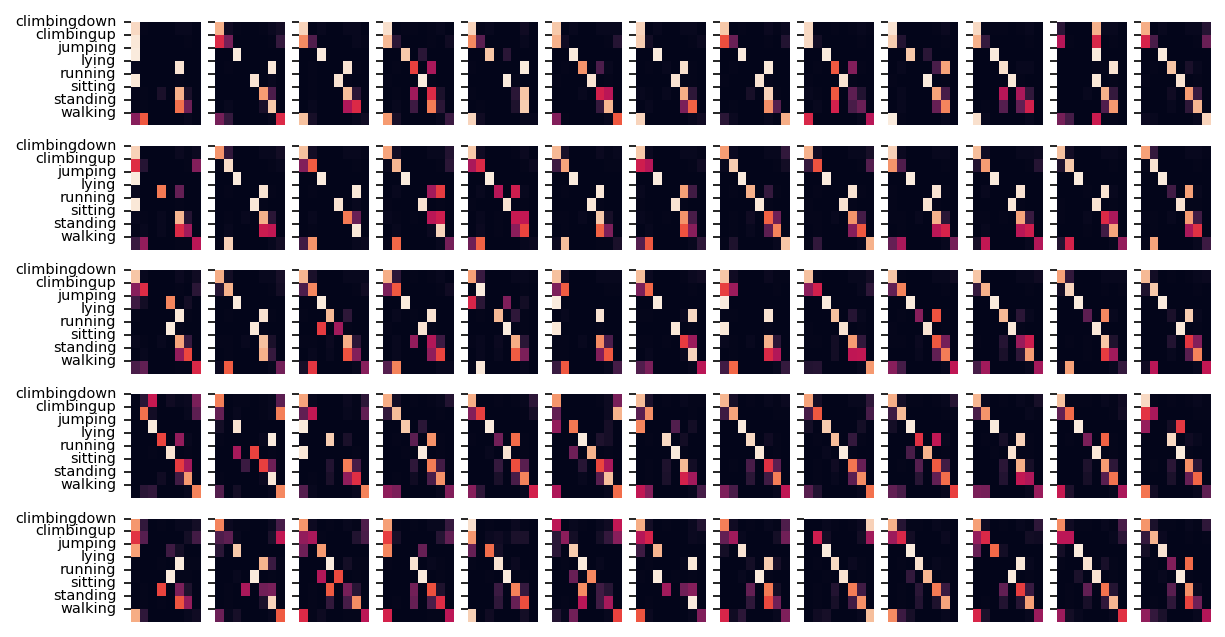

In [26]:
fig, ax = plt.subplots(5, 13, figsize=(8,5), sharex=True, sharey=True)
fig.subplots_adjust(bottom=0.12, top=0.92, left=0.07, right=0.97)

methods = [(f'SynNetRP,xylo,Realworld', 1.0),
           (f'SynNetRP,nimu,Realworld', 1.0),
           (f'SynNetRP,nimu,Realworld', 2.0),
           (f'SynNetRP,nimu,Realworld', 4.0),
           (f'SynNetRP,nimu,Realworld', 8.0)]
networks = [(i,i,i) for i in range(20, 85, 5)]

for mi, m in enumerate(methods):
    for ni, n in enumerate(networks):
        df = dFAllOpt[(dFAllOpt.method==m[0])*(dFAllOpt.tmCompress==m[1])*(dFAllOpt.nwSize==n)]
        cm = sum(df.confMat) / (sum(df.confMat).sum(1,keepdims=True) + 1e-5)
        sn.heatmap(np.round(100*cm), ax=ax[mi,ni], annot=False, cbar=False)
        # ax[spi,sri].set_title(f'Acc {int(df.TeAcc.mean()*100) if cm.sum() > 0 else 0}%')
        ax[mi,ni].set_yticks(np.arange(len(label_names_realworld)), label_names_realworld,
                             rotation='horizontal', fontsize='x-small')
        ax[mi,ni].set_xticks([])

# fig.savefig('../results/auroc_spikes.pdf', dpi=150)

(0.0, 1.0)

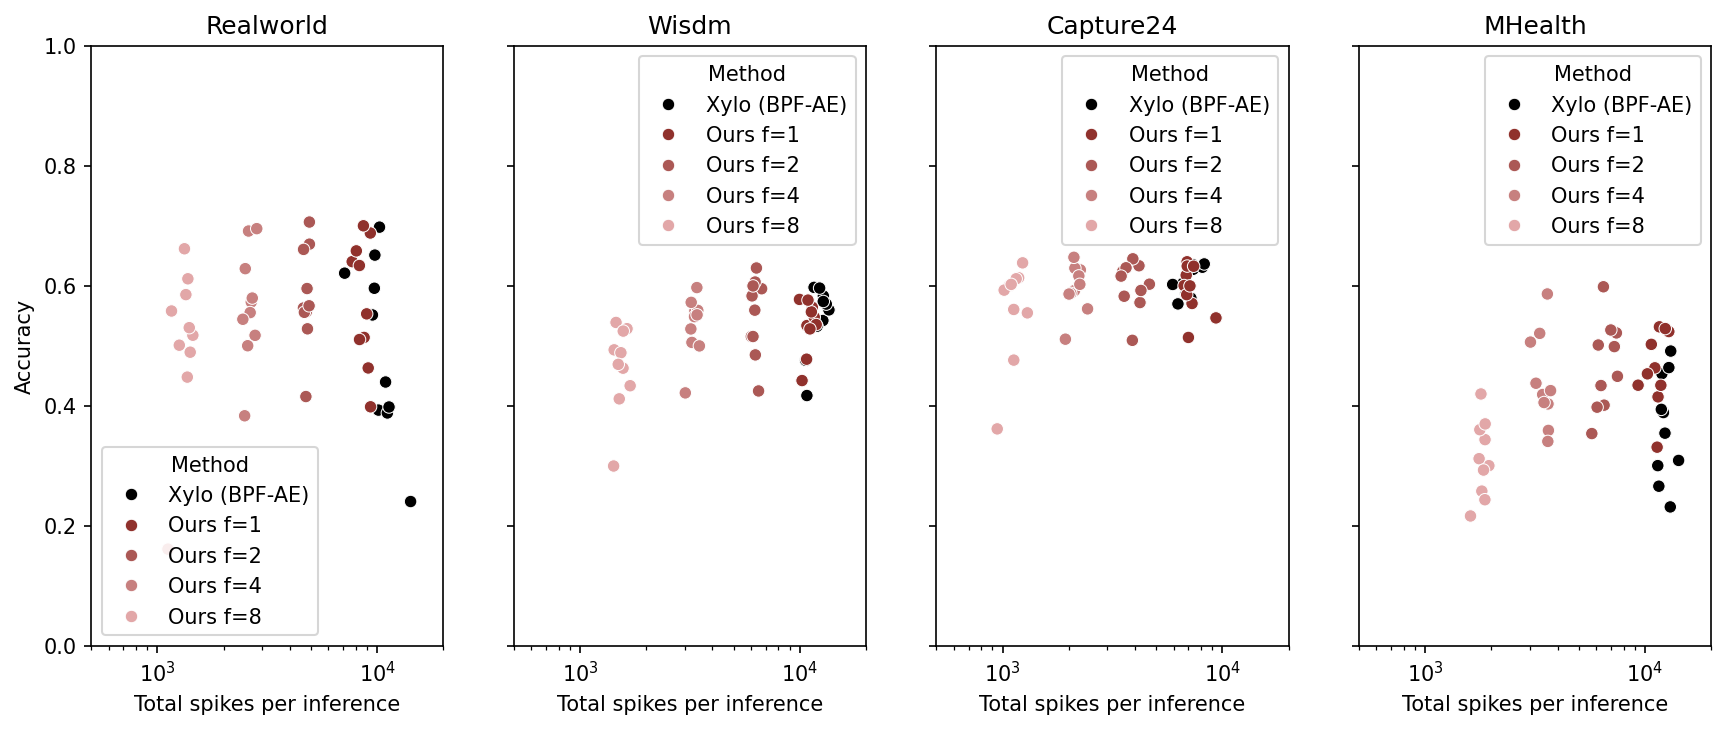

In [15]:
fig, ax = plt.subplots(1, 4, figsize=(12,5), sharex=True, sharey=True)
fig.subplots_adjust(bottom=0.12, top=0.92, left=0.07, right=0.97)

for axi, dataset in zip(ax, ['Realworld', 'Wisdm', 'Capture24', 'MHealth']):
    df = dFAllOpt[dFAllOpt['method'].str.contains(f'SynNetRP,.*,{dataset}', regex=True)].copy()
    # df.TeBalAcc *= 100
    df.TeSpk /= 5
    df.nwSize = df.nwSize.apply(sum)
    df = df.rename(columns={'TeBalAcc': 'Accuracy', 'nwSize': 'Neurons'})

    # original hue key (tuple)
    df["hue_key"] = df[['method','tmCompress']].apply(tuple, axis=1)

    # map to pretty names
    hue_order_key = [
        (f'SynNetRP,xylo,{dataset}', 1.0),
        (f'SynNetRP,nimu,{dataset}', 1.0),
        (f'SynNetRP,nimu,{dataset}', 2.0),
        (f'SynNetRP,nimu,{dataset}', 4.0),
        (f'SynNetRP,nimu,{dataset}', 8.0),
    ]
    hue_order = ['Xylo (BPF-AE)', 'Ours f=1', 'Ours f=2', 'Ours f=4', 'Ours f=8']

    label_map = dict(zip(hue_order_key, hue_order))
    df["Method"] = df["hue_key"].map(label_map)

    # keep order stable
    df["Method"] = pd.Categorical(df["Method"], categories=hue_order, ordered=True)

    sn.scatterplot(
        data=df,
        x='TeSpk', y='Accuracy',
        hue='Method',
        hue_order=hue_order,
        size_order=[40,50,60],
        sizes=(20, 100),
        palette=['black'] + sn.color_palette('blend:#90312C,#E2A7A8', n_colors=4),
        ax=axi
    )

    axi.set_title(dataset)
    axi.set_xlabel('Total spikes per inference')
    axi.set_ylabel('Accuracy')
    axi.set_ylim(0, 1)

axi.set_xscale('log')
axi.set_xlim(5e2, 2e4)
axi.set_ylim(0, 1)

# fig.savefig('../results/auroc_spikes.pdf', dpi=150)

# Plots

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(14,8), sharex=True, sharey=True)

splits = {'Train':'Tr', 'Validation':'Va', 'Test':'Te'}
for nsi, nwSize in enumerate([(24,24,24),(48,48,48),(96,96,96)]):
    for si, (split, s) in enumerate(splits.items()):
        sn.lineplot(dFAll[(dFAll.method=='nimu')*(dFAll.nwSize==nwSize)], x='epoch', y=f'{s}Acc', hue='tmCompress',
                    ax=ax[nsi,si], errorbar='ci', palette='tab10')
        ax[nsi,si].legend(title='Time compr. factor', loc='lower left')
    
[axj.grid() for axi in ax for axj in axi]
[axj.set_ylim(0,1) for axi in ax for axj in axi]
# [axi.set_yscale('logit', one_half='0.50') for axi in ax]
# [axi.yaxis.set_major_formatter(tck.ScalarFormatter()) for axi in ax]
[axj.set_xlabel('Epoch') for axi in ax for axj in axi]
[ax[nsi,0].set_ylabel(f'{nwSize}') for nsi, nwSize in enumerate([(24,24,24),(48,48,48),(96,96,96)])]
[ax[0,si].set_title(f'{split} Accuracy') for si, (split, s) in enumerate(splits.items())]

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(14,10), sharex=True, sharey=True)

pairs = [((1,'xylo'),(1,'nimu')),((1,'xylo'),(2,'nimu')),
         ((1,'xylo'),(4,'nimu')),((1,'xylo'),(8,'nimu'))]

splits = {'Train':'Tr', 'Validation':'Va', 'Test':'Te'}
annots = []

# [axij.set_ylim(0,1) for axi in ax for axij in axi]
# [axij.plot([0,0], [.6,.6], '') for axi in ax for axij in axi]

for nsi, nwSize in enumerate([3*(n*10,) for n in (2,4,8)]):
    for si, (split, s) in enumerate(splits.items()):
        df = dFAllOpt[dFAllOpt.nwSize == nwSize]
        
        # annots.append(Annotator(ax[nsi,si], pairs, data=df, x='tmCompress', y=f'{s}Acc',
        #                         order=[1,2,4,8], hue='method', hue_order=['xylo','nimu']))
        # annots[nsi].configure(test='Wilcoxon', verbose=2)
        # annots[nsi].apply_test()
        # annots[nsi].annotate()
            
        sn.violinplot(df, x='tmCompress', y=f'{s}AUCMi', hue='method',
                      order=None, hue_order=['xylo','nimu'], ax=ax[nsi,si])
        ax[nsi,si].legend(handles=ax[nsi,si].get_legend_handles_labels()[0], loc='lower right', labels=['Xylo','Ours'])
            
[axij.grid() for axi in ax for axij in axi]
[axij.set_ylim(0,1) for axi in ax for axij in axi]
[axij.set_xlabel('Compression factor') for axi in ax for axij in axi]
[axij.set_ylabel('') for axi in ax for axij in axi]
[ax[nsi,si].set_title(f'{split} AUROC') for si, (split, s) in enumerate(splits.items()) for nsi, nwSize in enumerate([(24,24,24),(48,48,48),(96,96,96)])]

display(dFAllOpt[['subjSplit','method','tmCompress','nwSize','TrAUCMi','VaAUCMi','TeAUCMi']]
        .groupby(['subjSplit','method','tmCompress','nwSize']).agg(['mean','std']).style.format('{:.3f}'))

In [ ]:
conf_mats = dict([(k, np.zeros(2*(len(label_names_adl),))) for k in dFAllOpt.id.unique()])
for run in tqdm(runs):
    h = dFAllOpt[dFAllOpt.id == run.id].epoch.to_numpy()[0].item()
    path = run.path
    try: artifact = api.artifact(f'{path[0]}/{path[1]}/run-{path[2]}-conf_mattest:v{h}')
    except: continue
    try: json_file = json.load(open(f'artifacts/run-{path[2]}-conf_mattest:v{h}/test.table.json'))
    except: json_file = json.load(open(artifact.download()+f'/conf_mat/test.table.json'))
    conf_mats[run.id] = np.array(json_file['data'])
dFAllOpt['confMat'] = [conf_mats[run_id] for run_id in dFAllOpt.id]

In [ ]:
fig, ax = plt.subplots(2, 4, figsize=(18,9), sharex=True, sharey=True)

for spi, split in enumerate([(35,5,5)]):
    # if spi != 2: continue
    for sri, sreg in enumerate(list(dFAllOpt[dFAllOpt.method=='xylo'].tmCompress.unique())):
        df = dFAllOpt[(dFAllOpt.subjSplit==split)*(dFAllOpt.tmCompress==sreg)*(dFAllOpt.method=='xylo')]
        cm = sum(df.confMat) / (sum(df.confMat).sum(1,keepdims=True) + 1e-5)
        sn.heatmap(np.round(100*cm), ax=ax[spi,sri], annot=True, cbar=False, fmt='.0f')
        # ax[spi,sri].set_title(f'Acc {int(df.TeAcc.mean()*100) if cm.sum() > 0 else 0}%')
        ax[spi,sri].set_yticklabels(label_names_wisdm, rotation='horizontal')

fig, ax = plt.subplots(2, 4, figsize=(18,9), sharex=True, sharey=True)

for spi, split in enumerate([(35,5,5)]):
    # if spi != 2: continue
    for sri, sreg in enumerate(list(dFAllOpt.tmCompress.unique())):
        df = dFAllOpt[(dFAllOpt.subjSplit==split)*(dFAllOpt.tmCompress==sreg)*(dFAllOpt.nwSize==(24,24,24))*(dFAllOpt.method=='nimu')]
        cm = sum(df.confMat) / (sum(df.confMat).sum(1,keepdims=True) + 1e-5)
        sn.heatmap(np.round(100*cm), ax=ax[spi,sri], annot=True, cbar=False, fmt='.0f')
        # ax[spi,sri].set_title(f'Acc {int(df.TeAcc.mean()*100) if cm.sum() > 0 else 0}%')
        ax[spi,sri].set_yticklabels(label_names_wisdm, rotation='horizontal')

# Per fold analysis

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(6,6), sharex=True, sharey=True)

metrics = {'(50,20,20)':(50,20,20),
           '(75,20,20)':(75,20,20),
           '(100,20,20)':(100,20,20)}
splits = {'Train':'Tr', 'Validation':'Va', 'Test':'Te'}

for mi, (metric, m) in enumerate(metrics.items()):
    for si, (split, s) in enumerate(splits.items()):
        dFAllPivot = dFAll.loc[(dFAll['epoch']>1)*(dFAll['subjSplit']==m)].pivot_table(
            index=['seed'], columns=['method'], values=f'{s}Acc', aggfunc={f'{s}Acc':['mean','std']}
        )
        # ax[mi,si].errorbar(dFAllPivot.loc['F1']['mean'][0], dFAllPivot.loc['F1']['mean'][1],
        #                    xerr=dFAllPivot.loc['F1']['std'][0], yerr=dFAllPivot.loc['F1']['std'][1],
        #                    ls='none', ecolor='k')
        sn.scatterplot(dFAllPivot['mean'], x='False', y='True', ax=ax[mi,si], hue='seed', palette='tab10')
        ax[mi,si].plot([0,1], [0,1], ls='--', color='black')
        ax[mi,si].yaxis.set_label_position('right')
        
        ax[mi,si].legend(handles=ax[mi,si].get_legend_handles_labels()[0], loc='lower left',
                         labels=[f'Fold {i}' for i in range(1,6)])
        ax[mi,si].grid()
        if mi == 0: ax[mi,si].set_title(f'{split}')
        if mi == len(metrics) - 1: ax[mi,si].set_xlabel(None)
        if mi != len(metrics)-1 or si != 0: ax[mi,si].get_legend().remove()
        
    ax[mi,0].set_ylabel(metric)

fig.supxlabel('Ours', size='medium', y=0.03)
fig.supylabel('Xylo', size='medium', x=0)

ax[0,0].set_ylim(0.,1)
ax[0,0].set_xlim(0.,1)

# Spike analysis

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14,3), sharex=True, sharey=True)

networks = dict([(str(t),t) for t in [3*(n*10,) for n in (2,4,8)]])

s = 'Te'

for ni, (networks, n) in enumerate(networks.items()):
    networks, n = '(80,80,80)', (80,80,80)
    sn.scatterplot(dFAllOpt[dFAllOpt.nwSize==n], x=f'{s}Spk', y=f'{s}AUCMi', ax=ax[ni],
                   hue=dFAllOpt[dFAllOpt.nwSize==n][['method','tmCompress']].apply(tuple, axis=1),
                   hue_order=[('xylo', 1.0), ('nimu', 1.0), ('nimu', 2.0), ('nimu', 4.0), ('nimu', 8.0)],
                   palette=['black']+sn.color_palette('blend:#3D4318,#7A8731,#BDCB6F', n_colors=4))
    
    handles, labels = ax[ni].get_legend_handles_labels()
    labels = ['Xylo', 'Ours 1.0', 'Ours 2.0', 'Ours 4.0', 'Ours 8.0']
    ax[ni].legend(handles=handles, loc='lower left', labels=labels, title='Method')
    ax[ni].grid()
    ax[ni].set_title(f'SynNet {n}')
    ax[ni].set_xlabel(f'Spk Count')
    # if ni != 2: ax[ni].get_legend().remove()
        
ax[0].set_ylabel('Test AUROC')

ax[0].set_ylim(0.,1)
ax[0].set_xlim(1e2, 1e5)
ax[0].set_xscale('log')

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14,3), sharex=True, sharey=True)

networks = dict([(str(t),t) for t in [3*(n*10,) for n in (2,4,8)]])

s = 'Te'

for ni, (networks, n) in enumerate(networks.items()):
    networks, n = '(80,80,80)', (80,80,80)
    sn.scatterplot(dFAllOpt[dFAllOpt.nwSize==n], x=f'{s}Spk', y=f'{s}Acc', ax=ax[ni],
                   hue=dFAllOpt[dFAllOpt.nwSize==n][['method','tmCompress']].apply(tuple, axis=1),
                   hue_order=[('xylo', 1.0), ('nimu', 1.0), ('nimu', 2.0), ('nimu', 4.0), ('nimu', 8.0)],
                   palette='rocket')
    
    handles, labels = ax[ni].get_legend_handles_labels()
    labels = ['Xylo', 'Ours 1.0', 'Ours 2.0', 'Ours 4.0', 'Ours 8.0']
    ax[ni].legend(handles=handles, loc='lower left', labels=labels, title='Method')
    ax[ni].grid()
    ax[ni].set_title(f'SynNet {n}')
    ax[ni].set_xlabel(f'Spk Count')
    if ni != 2: ax[ni].get_legend().remove()
        
ax[0].set_ylabel('Test Accuracy')

ax[0].set_ylim(0.,1)
ax[0].set_xlim(1e2, 1e5)
ax[0].set_xscale('log')

In [ ]:
dFAllOpt[['method', 'epoch', 'tmCompress', 'TeAcc', 'TeAUCMi', 'TeSpk']]